# 01 — Materials Sector Construction and EDA — FINAL REVISED

This notebook constructs the **dynamic top-50 Australian Materials portfolio** used by the final experiment.

Things to note:

- Input comes from Notebook 00: `data/interim/materials_equity_panel.parquet`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"
DIAG = ROOT / "results" / "diagnostics"

for p in [PROCESSED, TABLES, FIGURES, DIAG]:
    p.mkdir(parents=True, exist_ok=True)

MODEL_START = pd.Timestamp("2018-01-01")
TOP_N = 50

panel_file = INTERIM / "materials_equity_panel.parquet"
if not panel_file.exists():
    raise FileNotFoundError(
        f"Missing {panel_file}. Copy the scraped Materials equity panel produced by Notebook 00 "
        "into data/interim before running Notebook 01."
    )

panel = pd.read_parquet(panel_file).copy()
panel["Date"] = pd.to_datetime(panel["Date"])

required = {
    "Date", "Yahoo_Ticker", "Adj_Close", "Close",
    "High", "Low", "Volume", "Market_Cap_Reconstructed"
}
missing = sorted(required - set(panel.columns))
if missing:
    raise KeyError(f"Notebook 00 panel is missing required columns: {missing}")

panel = (
    panel.sort_values(["Yahoo_Ticker", "Date"])
    .drop_duplicates(["Yahoo_Ticker", "Date"], keep="last")
    .reset_index(drop=True)
)

print(f"Raw Materials tickers: {panel['Yahoo_Ticker'].nunique():,}")
print(f"Raw panel rows: {len(panel):,}")

Raw Materials tickers: 763
Raw panel rows: 1,997,744


## 1. Returns, lagged market capitalisation and eligibility

In [2]:
panel["Stock_Return"] = (
    panel.groupby("Yahoo_Ticker")["Adj_Close"]
    .pct_change(fill_method=None)
)

# A non-finite return is not a usable market observation.
panel["Stock_Return"] = panel["Stock_Return"].replace([np.inf, -np.inf], np.nan)

panel["Lagged_MCap"] = (
    panel.groupby("Yahoo_Ticker")["Market_Cap_Reconstructed"]
    .shift(1)
)

panel["Eligible_Day"] = (
    panel["Stock_Return"].notna()
    & np.isfinite(panel["Stock_Return"])
    & panel["Lagged_MCap"].gt(0)
    & np.isfinite(panel["Lagged_MCap"])
)

eligibility_audit = pd.DataFrame({
    "Metric": [
        "Raw panel rows",
        "Eligible stock-date rows",
        "Non-finite stock returns after cleaning",
        "Non-positive/non-finite lagged market cap rows"
    ],
    "Value": [
        len(panel),
        int(panel["Eligible_Day"].sum()),
        int((panel["Stock_Return"].notna() & ~np.isfinite(panel["Stock_Return"])).sum()),
        int((~panel["Lagged_MCap"].gt(0) | ~np.isfinite(panel["Lagged_MCap"].fillna(np.nan))).sum())
    ]
})
display(eligibility_audit)
eligibility_audit.to_csv(DIAG / "01_eligibility_audit.csv", index=False)

,Metric,Value
0,Raw panel rows,1997744
1,Eligible stock-date rows,1355330
2,Non-finite stock returns after cleaning,0
3,Non-positive/non-finite lagged market cap rows,639732


## 2. Dynamic top-50 lagged-market-cap portfolio

In [3]:
eligible = panel.loc[panel["Eligible_Day"]].copy()

eligible["MCap_Rank"] = (
    eligible.groupby("Date")["Lagged_MCap"]
    .rank(method="first", ascending=False)
)

top = eligible.loc[eligible["MCap_Rank"] <= TOP_N].copy()

top["Denominator"] = (
    top.groupby("Date")["Lagged_MCap"]
    .transform("sum")
)

top["Weight"] = top["Lagged_MCap"] / top["Denominator"]
top["Contribution"] = top["Weight"] * top["Stock_Return"]

daily = (
    top.groupby("Date")
    .agg(
        Sector_Return=("Contribution", "sum"),
        N_Constituents=("Yahoo_Ticker", "nunique"),
        Represented_MCap=("Lagged_MCap", "sum"),
        Weight_Sum=("Weight", "sum"),
    )
    .reset_index()
)

daily = daily.loc[daily["Date"] >= MODEL_START].copy()

# Keep exactly the same selected stock-date rows for Notebook 02.
top_final = top.loc[top["Date"] >= MODEL_START].copy()

assert daily["N_Constituents"].le(TOP_N).all()
assert np.allclose(daily["Weight_Sum"], 1.0, atol=1e-10)
assert np.isfinite(daily["Sector_Return"]).all()
assert not top_final.duplicated(["Date", "Yahoo_Ticker"]).any()

daily.to_csv(PROCESSED / "materials_daily_returns.csv", index=False)
daily.to_parquet(PROCESSED / "materials_daily_returns.parquet", index=False)
top_final.to_parquet(PROCESSED / "materials_top50_panel.parquet", index=False)

print("Date range:", daily["Date"].min(), "to", daily["Date"].max())
print("\nConstituent count:")
display(daily["N_Constituents"].describe())
print("\nSector return:")
display(daily["Sector_Return"].describe())

Date range: 2018-01-02 00:00:00 to 2026-09-18 00:00:00

Constituent count:


count    2207.0
mean       50.0
std         0.0
min        50.0
25%        50.0
50%        50.0
75%        50.0
max        50.0
Name: N_Constituents, dtype: float64


Sector return:


count    2207.000000
mean        0.000900
std         0.034418
min        -0.170560
25%        -0.009310
50%         0.000519
75%         0.010299
max         0.212396
Name: Sector_Return, dtype: float64

## 3. Coverage and integrity diagnostics

In [4]:
daily["Calendar_Gap_Days"] = daily["Date"].diff().dt.days

gap_audit = daily.loc[
    daily["Calendar_Gap_Days"] > 7,
    ["Date", "Calendar_Gap_Days", "N_Constituents"]
].copy()

print("Infinite sector returns:", int(np.isinf(daily["Sector_Return"]).sum()))
print("Calendar gaps > 7 days:", len(gap_audit))
display(gap_audit)

annual = (
    daily.assign(Year=daily["Date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(
        Observations=("Sector_Return", "count"),
        Mean_Constituents=("N_Constituents", "mean"),
        Min_Constituents=("N_Constituents", "min"),
        Max_Constituents=("N_Constituents", "max"),
        Mean_Weight_Sum=("Weight_Sum", "mean"),
    )
)

annual.to_csv(TABLES / "01_annual_coverage.csv", index=False)
gap_audit.to_csv(DIAG / "01_calendar_gap_audit.csv", index=False)

display(annual)

# Fail loudly if an old broad-universe result is accidentally regenerated.
if annual["Max_Constituents"].max() > TOP_N:
    raise AssertionError("Constituent count exceeds the locked top-50 universe.")

Infinite sector returns: 0
Calendar gaps > 7 days: 0


,Date,Calendar_Gap_Days,N_Constituents


,Year,Observations,Mean_Constituents,Min_Constituents,Max_Constituents,Mean_Weight_Sum
0,2018,253,50.0,50,50,1.0
1,2019,253,50.0,50,50,1.0
2,2020,255,50.0,50,50,1.0
3,2021,254,50.0,50,50,1.0
4,2022,251,50.0,50,50,1.0
5,2023,252,50.0,50,50,1.0
6,2024,254,50.0,50,50,1.0
7,2025,253,50.0,50,50,1.0
8,2026,182,50.0,50,50,1.0


## 4. EDA

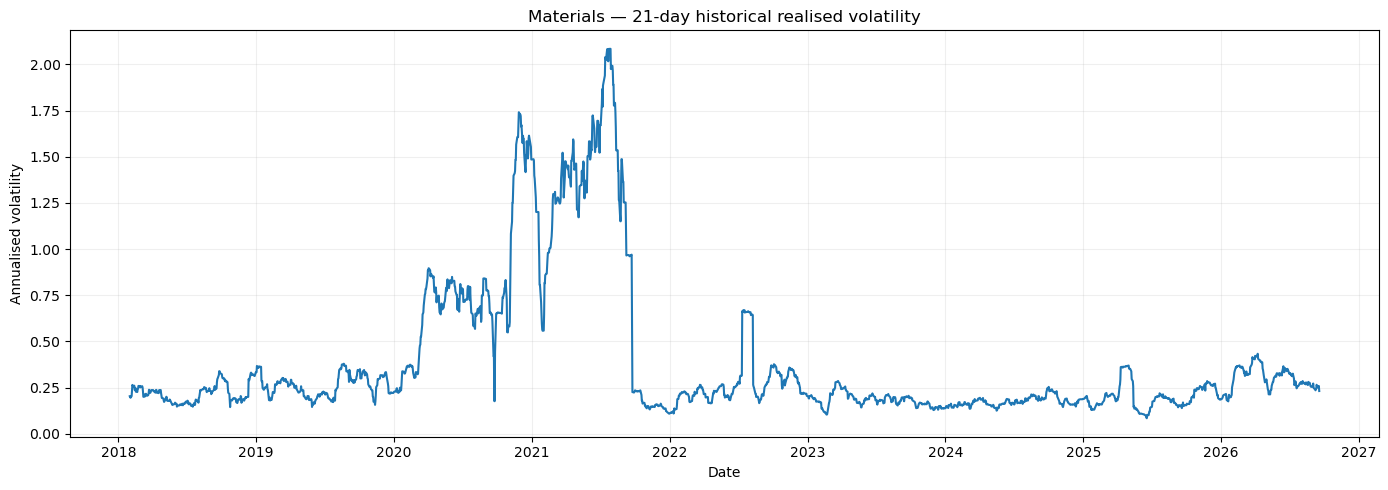

,count,mean,std,min,25%,50%,75%,max
Sector_Return,2207.0,8.997692e-04,3.441769e-02,-1.705604e-01,-9.309916e-03,5.187744e-04,1.029852e-02,2.123960e-01
RV21,2187.0,3.860540e-01,3.897041e-01,8.464219e-02,1.803148e-01,2.306285e-01,3.388673e-01,2.083992e+00
N_Constituents,2207.0,5.000000e+01,0.000000e+00,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01
Represented_MCap,2207.0,7.566104e+11,2.012364e+11,3.861571e+11,5.610277e+11,7.703969e+11,8.454365e+11,1.333388e+12


In [5]:
daily["RV21"] = np.sqrt(
    252 * daily["Sector_Return"].pow(2).rolling(21).mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["Date"], daily["RV21"])
ax.set_title("Materials — 21-day historical realised volatility")
ax.set_ylabel("Annualised volatility")
ax.set_xlabel("Date")
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIGURES / "01_materials_RV21.png", dpi=300, bbox_inches="tight")
plt.show()

summary = daily[["Sector_Return", "RV21", "N_Constituents", "Represented_MCap"]].describe().T
summary.to_csv(TABLES / "01_sector_summary.csv")
display(summary)